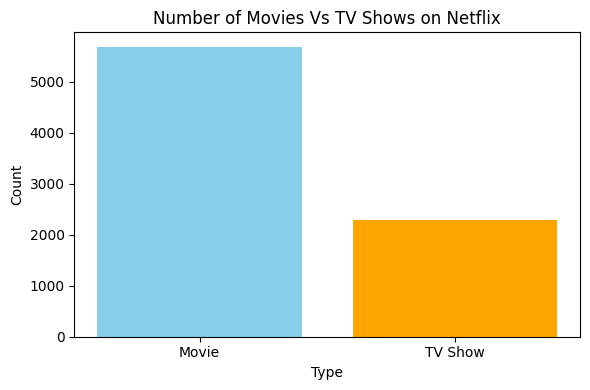

In [5]:
# import the libraries
import pandas as pd
import matplotlib.pyplot as plt

#load the data
df = pd.read_csv('netflix_titles.csv/netflix_titles.csv')

# Clean data
df = df.dropna(subset = ['type', 'release_year', 'rating', 'country', 'duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'orange'])
plt.title('Number of Movies Vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()


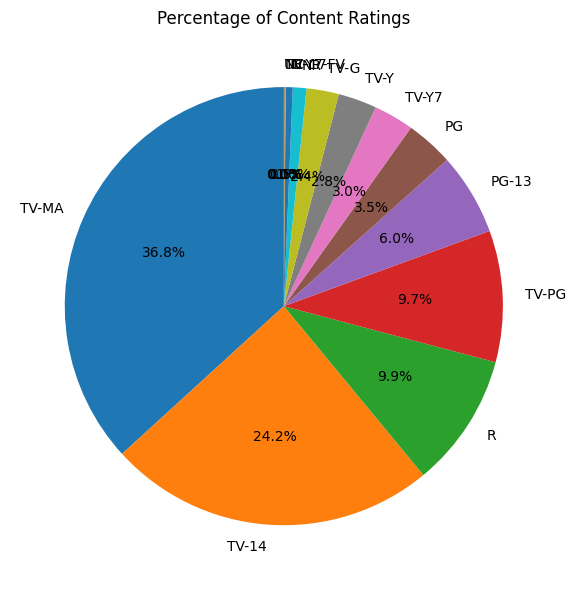

In [7]:
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(rating_counts, labels=rating_counts.index,  autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Content Ratings')
plt.tight_layout()
plt.savefig('contents_pie.png')
plt.show()

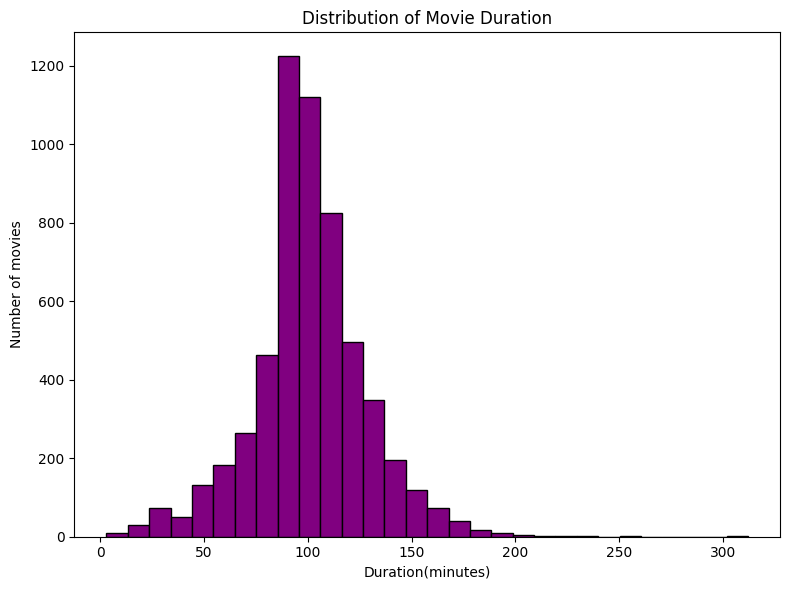

In [11]:
# Movies duration distribution

movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min', '').astype(int)

plt.figure(figsize=(8, 6))
plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor= 'black')
plt.title("Distribution of Movie Duration")
plt.xlabel('Duration(minutes)')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.savefig('movie_duration_histogram.png')
plt.show()


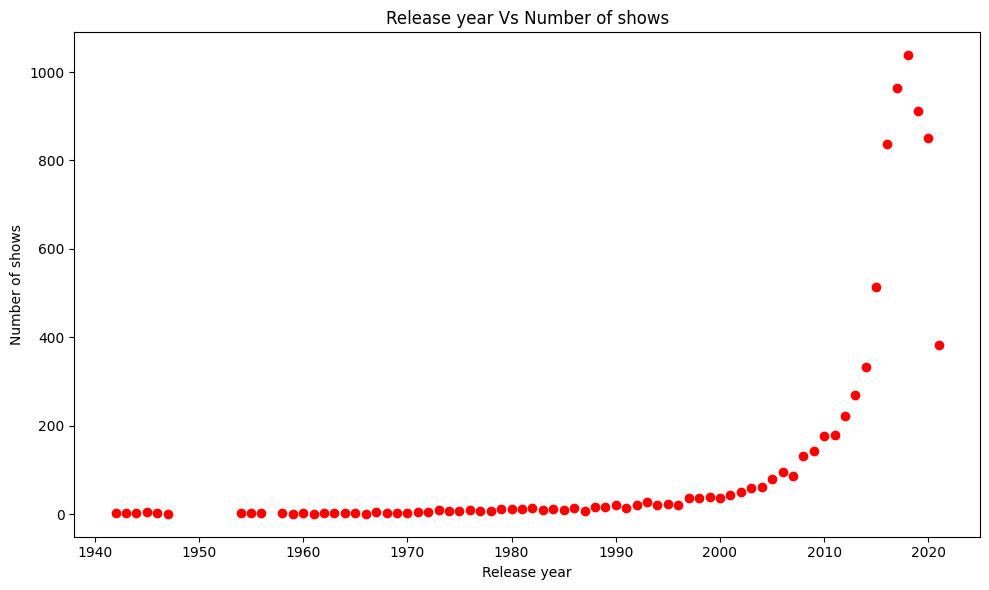

In [13]:
release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.scatter(release_counts.index, release_counts.values, color='red')
plt.title("Release year Vs Number of shows")
plt.xlabel('Release year')
plt.ylabel('Number of shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()

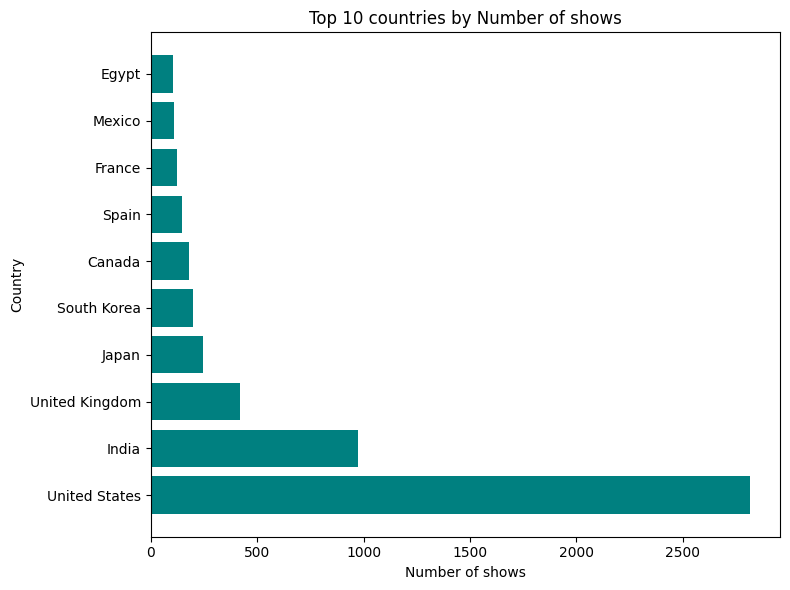

In [15]:
country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8, 6))
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title("Top 10 countries by Number of shows")
plt.xlabel('Number of shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()


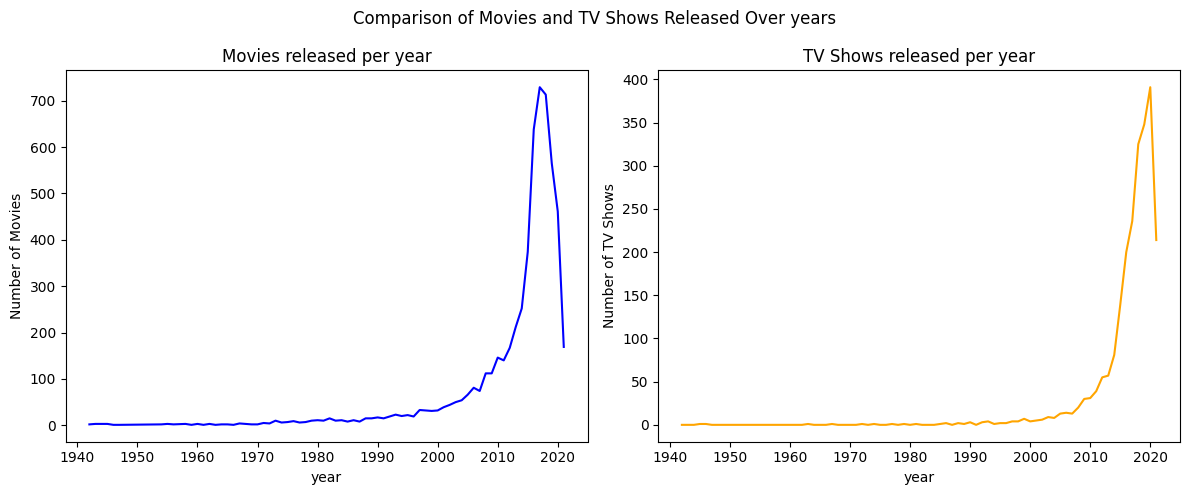

In [17]:
content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# first subplots: movies
ax[0].plot(content_by_year.index, content_by_year['Movie'],  color='blue')
ax[0].set_title("Movies released per year")
ax[0].set_xlabel('year')
ax[0].set_ylabel('Number of Movies')


# first subplots: TV Shows
ax[1].plot(content_by_year.index, content_by_year['TV Show'],  color='orange')
ax[1].set_title("TV Shows released per year")
ax[1].set_xlabel('year')
ax[1].set_ylabel('Number of TV Shows')

fig.suptitle('Comparison of Movies and TV Shows Released Over years')
plt.tight_layout()
plt.savefig('movies_tv_shows_comparison.png')
plt.show()